# IMPORTATION DE BIBLIOTHEQUES


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Pamètres de référence

In [63]:
S0 = 100
K= 100
T = 1
N = 500 #nombre de noeuds
r = 0.05
sigma = 0.20
q=0

# 1. Arbre binomial et modèle CRR

## Cas particulier

In [ ]:
j = np.arange (N+1)
dt = T/N
u = np.exp (sigma * np.sqrt (dt))
d= 1/u

option_type = 'put'
exercice = 'american'

p = (np.exp (r*dt) - d) / (u-d) #probabilité de risque-neutre
j = np.arange(N+1)
ST = S0 * (u ** j) * (d ** (N - j)) #Valeurs finales du sous-jacent au bout de l'arbre
#print (ST)



if option_type == 'call' : 
    values = np.maximum (ST - K, 0.0)
elif option_type == 'put' :
    values = np.maximum (K-ST,0.0)


for i in range (N,0,-1) :
    values =  np.exp (- r * dt) * (p * values [1:] + (1-p) * values [:-1])
    if exercice == 'american' :
        j_i = np.arange (i)
        S_i = S0 * (u**(j_i)) * (d**(i-1-j_i))
        if option_type == 'call' :
            exe_value = np.maximum (S_i-K, 0)
        elif option_type == 'put' :
            exe_value = np.maximum (K - S_i, 0)
        values = np.maximum (exe_value, values)

print (values)

6.088810110703037


## Fonction générale

In [82]:
def crr_binomial_price (S0, K, T, r, sigma, N, option_type = 'call', exercise = 'european') :
    j = np.arange (N+1)
    dt = T/N
    u = np.exp (sigma * np.sqrt (dt))
    d= 1/u

    j = np.arange(N+1)
    ST = S0 * (u ** j) * (d ** (N - j)) #Valeurs finales du sous-jacent au bout de l'arbre
    #print (ST)

    p = (np.exp (r*dt) - d) / (u-d) 
    if option_type == "call" :
        values = np.maximum (ST - K, 0.0)
    elif option_type == 'put' :
        values = np.maximum (K-ST, 0.0)
    for i in range (N,0,-1) :  #procédure de backward pour un arbre binomial avec N-1 noeuds à chaque itération
        values =  np.exp (- r * dt) * (p * values [1:] + (1-p) * values [:-1])
        if exercise == 'american' :
            j_i = np.arange (i)
            S_i = S0 * (u ** j_i) * (d ** (i-1-j_i))
            if option_type == 'call' :
                exe_values = np.maximum (S_i - K, 0)
            elif option_type == 'put' :
                exe_values = np.maximum (K - S_i, 0)
            values = np.maximum (exe_values, values)

    return values [0]

## Vérification de cohérence

Un put américain doit toujours valoir **au moins autant** qu'un put européen (l'exercice anticipé est une option supplémentaire, jamais une contrainte). Vérifions-le :

In [293]:
price_eu_put = crr_binomial_price(S0, K, T, r, sigma, N=500, option_type="put", exercise="european")
price_us_put  = crr_binomial_price(S0, K, T, r, sigma, N=500, option_type="put", exercise="american")

print(f"Put européen  : {price_eu_put:.4f}")
print(f"Put américain : {price_us_put:.4f}")
print(f"Prime d'exercice anticipé : {price_us_put - price_eu_put:.4f}  (doit être >= 0)")

assert price_us_put >= price_eu_put - 1e-8, "Erreur : le put américain ne peut pas valoir moins que l'européen"

Put européen  : 5.5695
Put américain : 6.0888
Prime d'exercice anticipé : 0.5193  (doit être >= 0)


# 2. Modèle de Black-Scholes + Greeks

## Formule du call

In [ ]:
d1 = (np.log (S0/K) + (r - q+ 0.5 * sigma**2) * T) / (sigma * np.sqrt (T))
d2 = d1 - sigma * np.sqrt (T)

print (d1, d2)

C = S0 * norm.cdf (d1) - K * np.exp (-r*T) * norm.cdf (d2)
print (C)

0.35000000000000003 0.15000000000000002
10.450583572185565


## Formule du put

In [ ]:
P1 = C - S0 * np.exp (-q * T) + K*np.exp (-r * T) #en utlisant la parité put-call

P2 = K * np.exp (- r*T) * norm.cdf (-d2) - S0* np.exp (-q*T) * norm.cdf (-d1) #en utilisant Black-Scholes

print (P1, P2)

5.573526022256971 5.573526022256971


## Greeks

In [286]:
delta = np.exp (-q *T) * norm.cdf (d1)

gamma = np.exp (-q * T) * norm.pdf (d1) / (S0 * sigma * np.sqrt (T))

vega = S0 * np.exp (-q* T) * norm.pdf (d1) * np.sqrt (T)

theta = - S0 * norm.pdf (d1) * sigma * np.exp (-q * T) / (2 * np.sqrt (T)) - r * K*np.exp (-r * T) * norm.cdf (d2) + q * S0 * np.exp (-q * T) * norm.cdf (d1)

rho = K * T* np.exp (-r * T) * norm.cdf (d2)

print (f'Greeks pour le call européen \n'
       f'Delta : {delta}\n'
       f'Gamma : {gamma}\n'
       f'Vega : {vega}\n'
       f'Theta : {theta}\n'
       f'Rho : {rho}')

Greeks pour le call européen 
Delta : 0.6368306511756191
Gamma : 0.018762017345846895
Vega : 37.52403469169379
Theta : -6.414027546438197
Rho : 53.232481545376345


## Fonction générale

In [ ]:
def black_scholes (S0, K, T, r, sigma, option_type = 'call', q= 0) :
    d1 = (np.log (S0/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt (T))
    d2 = d1 - sigma * np.sqrt (T)

    gamma = np.exp (-q * T) * norm.pdf (d1) / (S0 * sigma * np.sqrt (T))
    vega = S0 * np.exp (-q* T) * norm.pdf (d1) * np.sqrt (T)


    if option_type == 'call' : 
        Prix = S0 * np.exp (-q * T) * norm.cdf (d1) - K * np.exp (-r*T) * norm.cdf (d2)
        delta = np.exp (-q *T) * norm.cdf (d1)
        theta = - S0 * norm.pdf (d1) * sigma * np.exp (-q * T) / (2 * np.sqrt (T)) - r * K*np.exp (-r * T) * norm.cdf (d2) + q * S0 * np.exp (-q * T) * norm.cdf (d1)
        rho = K * T* np.exp (-r * T) * norm.cdf (d2)
    
    elif option_type == 'put' :
        Prix = K * np.exp (-r * T) * norm.cdf (-d2) - S0 * np.exp (-q * T) * norm.cdf (-d1)
        delta = np.exp (-q *T) * (norm.cdf (d1) - 1)
        theta = - S0 * norm.pdf (d1) * sigma * np.exp (-q * T) / (2 * np.sqrt (T)) + r * K*np.exp (-r * T) * norm.cdf (-d2) - q * S0 * np.exp (-q * T) * norm.cdf (-d1)
        rho = -K * T* np.exp (-r * T) * norm.cdf (-d2)

    return dict ( prix = Prix, Gamma = gamma, Vega = vega, Delta = delta, Theta = theta, Rho = rho )
            

In [88]:
black_scholes (S0, K, T, r, sigma, option_type='put')

{'prix': np.float64(5.573526022256971),
 'Gamma': np.float64(0.018762017345846895),
 'Vega': np.float64(37.52403469169379),
 'Delta': np.float64(-0.3631693488243809),
 'Theta': np.float64(-1.657880423934626),
 'Rho': np.float64(-41.89046090469506)}

# 3. Etude de convergence de l'arbre binomial vers Black-Scholes

In [292]:
N = np.array ([10,20, 50, 100, 200, 500, 1000, 2000])
erreurs = []

for i in N : 
    m = crr_binomial_price (S0, K, T, r, sigma, i, option_type = 'call', exercise='european')
    p = black_scholes (S0, K, T, r, sigma, option_type = 'call') ['prix']
    erreur = m - p
    erreurs.append (abs (erreur))

erreurs = np.array (erreurs)
for n_valeurs, err_val in zip (N, erreurs) :
    print (f'N = {n_valeurs : >5} | erreur : {err_val:.6f}')

N =    10 | erreur : 0.197175
N =    20 | erreur : 0.099323
N =    50 | erreur : 0.039892
N =   100 | erreur : 0.019972
N =   200 | erreur : 0.009992
N =   500 | erreur : 0.003998
N =  1000 | erreur : 0.001999
N =  2000 | erreur : 0.001000


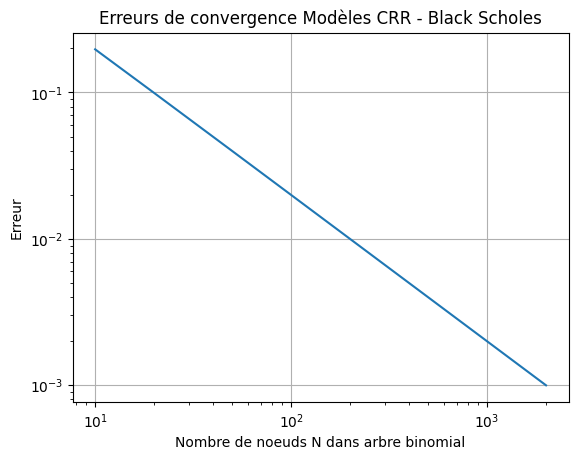

In [127]:
#Représentation graphique 

plt.loglog (N, erreurs)
plt.title ('Erreurs de convergence Modèles CRR - Black Scholes')
plt.xlabel ('Nombre de noeuds N dans arbre binomial')
plt.ylabel ('Erreur')
plt.grid()
plt.show()

In [126]:
x = np.polyfit (np.log (N), np.log (erreurs), 1)
print (f'Pente = {x[0]}')

Pente = -0.9978373439616803


Le graphique est mis à l'échelle log-log afin d'identifier si l'erreur suit une loi du type C * N ^ (-alpha)

La pente de la droite est -0.9978, cette valeur repprésente l'ordre de convergence de la droite. 

Donc log (erreur) = log (C)- alpha * log (N) ~ log (C) + Log (N)

# 4. Simulations de Monte-Carlo

## Calcul du prix de l'option par Monte Carlo

In [294]:
#Simulations des prix finaux du sous jacents
np.random.seed (42)

Z = np.random.standard_normal (100000)

S_T = S0 * np.exp ((r-q-0.5*sigma**2) * T + Z * sigma * np.sqrt (T))


print (f'5 premières valeurs de St : {S_T [:5]}\n'
       f'Moyenne de St : {np.mean (S_T)}' )

print (S0 * np.exp ((r-q) * T))

5 premières valeurs de St : [113.8080226  100.23498965 117.29684912 139.73896651  98.33101696]
Moyenne de St : 105.15091963567757
105.12710963760242


Le prix Monte Carlo est une **moyenne empirique** calculée sur $M$ tirages indépendants (les payoffs actualisés). D'après le théorème central limite, cette moyenne suit approximativement une loi normale :

$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{M}\right)$$

où $\sigma^2$ est la variance d'un tirage individuel (un payoff actualisé), et $\dfrac{\sigma^2}{M}$ est la variance de la moyenne.

L'écart-type de cette moyenne est donc :

$$\text{erreur standard} = \frac{\sigma}{\sqrt{M}}$$

Pour une loi normale, 95 % de la masse de probabilité se situe dans l'intervalle $\mu \pm 1.96\,\sigma$. L'intervalle de confiance à 95 % de notre estimateur Monte Carlo est donc :

$$\text{Prix} \pm 1.96 \times \frac{\sigma_{\text{payoffs}}}{\sqrt{M}}$$

In [295]:
#Pricing de l'option
payoff = np.maximum (S_T - K, 0)
prix_monte_carlo = np.mean (payoff) * np.exp (-r*T)

interval_sup = prix_monte_carlo + 1.96 * (np.std (payoff)/np.sqrt(100000))  
interval_inf = prix_monte_carlo - 1.96 * (np.std (payoff)/np.sqrt(100000))

print (f'prix du call : {prix_monte_carlo}\n'
       f"Intervalle supérieur de l'estimation : {interval_sup}\n"
       f"Intervalle inférieur de l'estimation : {interval_inf}")

prix du call : 10.47389196070258
Intervalle supérieur de l'estimation : 10.56988834442465
Intervalle inférieur de l'estimation : 10.377895576980512


## Réduction de variance - Technique des variables antithétiques

L'intervalle de confiance calculé a une largeur d'environ 0.096 autour du prix 10.474.
Nous allons procéder à une réduction de variance par variables antithétique, elle permet d'obtenir une plus grande précision qu'une simple simulation MC, mais avec moins de simulations qu'une technique telle que l'augmentation de d'échantillons M.

In [181]:
#Génération des trajectoires antithétiques
S_T_anti = S0 * np.exp ((r- q- 0.5 * sigma**2)*T - Z * sigma * np.sqrt (T)) #la différence ici on utilise -z, précédemment nous avons utilisé +Z
payoff_anti = np.maximum (S_T_anti - K, 0)

print(payoff_anti [:10])

#Calcul du nouveau prix du call
payoff_combine = (payoff + payoff_anti) / 2
print (payoff_combine)

prix_combine = np.exp (-r*T) * np.mean (payoff_combine)
interval_sup_c = prix_combine + 1.96 * (np.std (payoff_combine)/np.sqrt(100000))  
interval_inf_c = prix_combine - 1.96 * (np.std (payoff_combine)/np.sqrt(100000))

print (f'prix du call : {prix_combine}\n'
       f"Intervalle supérieur de l'estimation : {interval_sup_c}\n"
       f"Intervalle inférieur de l'estimation : {interval_inf_c}\n"
       f"Largeur intervalle précédent : {interval_sup - interval_inf}\n"
       f"Largeur nouvel intervalle : {interval_sup_c - interval_inf_c}")

[ 0.          5.93471903  0.          0.          7.98592137  7.98556679
  0.          0.         13.18968766  0.        ]
[6.9040113  3.08485434 8.64842456 ... 5.91652877 3.74450018 3.07516305]
prix du call : 10.461149722289003
Intervalle supérieur de l'estimation : 10.509074362007095
Intervalle inférieur de l'estimation : 10.41322508257091
Largeur intervalle précédent : 0.1919927674441375
Largeur nouvel intervalle : 0.09584927943618382


Nous terminons donc avec un intervalle d'une largeur de 0.096 autour du prix de 10.46, soit une réduction d'environ 50%, ce qui est plus précis que le résultat précédent

# 5. Application du Lemme d'Ito

Dans ce chapitre nous essayons de vérifier la propriété mathématique du Lemme d'Itô, càd que la transformation appliquée à ln(St) donne bien ce que la théorie prédit.
En effet, le Lemme d'Itô repose sur une dimension infinitésimale, nous allons donc simuler plusieurs petits temps successifs (252 jours de trading pour T=1an) et en comparant la moyenne numérique ((r-q-0.5 * sigma**2)/dt) et la variance (sigma**2 * dt) 

In [ ]:
#Simulation des trajectoires
N_steps = 252 #nombre de jours de trading
M = 100000 #nombre de simulations
dt = T/N_steps

Z = np.random.standard_normal ((M,N_steps))
dlogS = (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt (dt) * Z
#print (dlogS [0:10,:10]) 


#Comparaisons
moy_emp = np.mean (dlogS)
moy_the = (r - q- 0.5 * sigma**2) * dt
var_emp = np.var (dlogS)
var_the = dt * sigma**2
ecart_moy = abs((moy_emp - moy_the)/moy_the) * 100 #ecart relatif pour les moyennes
ecart_var = abs ((var_emp - var_the)/var_the) * 100 #ecart relatif pour les variances

print (f'Moyenne empirique : {moy_emp:.8f}\n'
       f'Variance empirique : {var_emp:.8f}\n'
       f'Moyenne théorique : {moy_the:.8f}\n'
       f'Variance théorique : {var_the:.8f}\n'
       f'Ecart moyenne : {ecart_moy}%\n'
       f'Ecart variance : {ecart_var}%')

(252,)
Moyenne empirique : 0.00011890
Variance empirique : 0.00015871
Moyenne théorique : 0.00011905
Variance théorique : 0.00015873
Ecart moyenne : 0.1279048564338959%
Ecart variance : 0.015715972951300925%


Les deux écarts sont faibles (< 1%), ce qui valide numériquement le lemme d'Itô appliqué à ln (𝑆𝑡): le drift et la diffusion empiriques des trajectoires simulées correspondent bien à ce que prédit la théorie

# 6. Convergence Monte Carlo + comparaison des Greeks   

## Convergence Modèles MC - Black-Scholes

In [ ]:
#simulation des prix
M = np.array([100, 500, 1000, 5000, 10000, 50000, 100000, 500000])
K_runs = 20
err = []
for i in M : 
    Z = np.random.standard_normal ((i, K_runs)) #ici on effectue (k_runs*M) simulations à chaque itération, cette procédure est utile afin de diminuer le bruit dans nos erreurs
    S_T = S0 * np.exp ((r-q- 0.5 * sigma**2) * T + sigma * np.sqrt (T) * Z )
    payoff_sim = np.maximum (S_T - K, 0)
    prix_sim = np.mean (payoff_sim, axis = 0) * np.exp (-r *T)  #moyenne par colonne, on ressort avec une matrice (20,)
    err_sim = abs (prix_sim - black_scholes (S0, K, T, r, sigma, option_type = 'call') ['prix'])
    err.append (np.mean (err_sim))

err = np.array (err)
print (err)

for i, erreur in zip (M, err) :
    print (f' M = {i : <7} | erreur = {erreur:.10f}')

[1.17031848 0.55082448 0.3344549  0.15114504 0.11931426 0.04810464
 0.02956664 0.01892653]
 M = 100     | erreur = 1.1703184759
 M = 500     | erreur = 0.5508244817
 M = 1000    | erreur = 0.3344548993
 M = 5000    | erreur = 0.1511450434
 M = 10000   | erreur = 0.1193142556
 M = 50000   | erreur = 0.0481046361
 M = 100000  | erreur = 0.0295666363
 M = 500000  | erreur = 0.0189265254


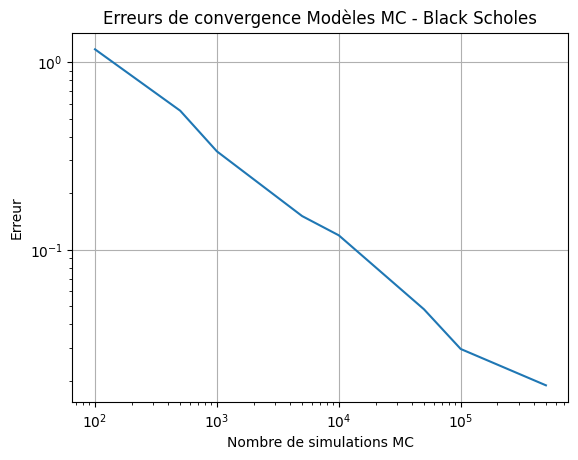

Pente = -0.5015076307763806


In [283]:
#Représentation graphique 
plt.loglog (M, err)
plt.title ('Erreurs de convergence Modèles MC - Black Scholes')
plt.xlabel ('Nombre de simulations MC')
plt.ylabel ('Erreur')
plt.grid()
plt.show()


#Calcul de la pente
x = np.polyfit (np.log (M), np.log (err), 1)
print (f'Pente = {x[0]}')

## Greeks analytiques

Ici, au lieu d'utiliser la formule de delta on va l'estimer numériquement en pertubant légèrement S0 et en observant comment le prix de l'option réagit.

Le but est d'estimer des Greeks de manière analytique afin de valider le modèle utilisé car en réalité la plupart des méthodes de pricing n'ont pas de formule définie pour les greeks.

La méthode utilisée ici est la méthode des différences finies

In [290]:
#Estimation du delta par différences finies
epsilon = 0.01
prix_plus = black_scholes (S0 + epsilon, K, T, r, sigma, option_type ='call')['prix']
prix_moins = black_scholes (S0 - epsilon, K, T, r, sigma, option_type ='call')['prix']

delta_fd = (prix_plus - prix_moins) / (2 * epsilon)
delta_analyt = black_scholes (S0, K, T, r, sigma, option_type ='call')['Delta']

print (f'Delta par différence finie centrée : {delta_fd}\n'
       f'Delta analytique : {delta_analyt}')

Delta par différence finie centrée : 0.6368306425763137
Delta analytique : 0.6368306511756191


In [291]:
#Estimation du Gamma par différence finie

prix_S0 = black_scholes (S0, K, T, r, sigma, option_type ='call')['prix']

gamma_fd = (prix_plus - 2 * prix_S0 + prix_moins) / (epsilon**2)
gamma_analyt = black_scholes (S0, K, T, r, sigma, option_type ='call')['Gamma']

print (f'Gamma par différence finie centrée : {gamma_fd}\n'
       f'Gamma analytique : {gamma_analyt}')

Gamma par différence finie centrée : 0.018762017077733617
Gamma analytique : 0.018762017345846895


N.B. Ici nous n'avons pas effectué de validation de modèle proprement dite, nous avons vérifié que notre infrastructure numérique est correcte/fiable.